<a href="https://colab.research.google.com/github/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# Caso a consulta da API falhar:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
dados.head(20)

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


In [6]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=dados)

https://docs.google.com/spreadsheets/d/1_aT6gvbqy0vULXvtL_89XxwMBgGIqWPUixcgogS5HHQ/edit#gid=0


In [7]:
print("Informações do Dataset:")
print(dados.info())

print("\nValores ausentes por coluna:")
print(dados.isna().sum())

print("\nContagem por classe (Fonte):")
print(dados['fonte'].value_counts())

print("\nDistribuições relevantes (Estatísticas descritivas):")
print(dados.describe())

X = dados[['potencia_kw', 'latitude', 'longitude']]

y = dados['fonte']

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB
None

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Contagem por classe (Fonte):
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

Distribuições relevantes (Estatísticas descritivas):
        potencia_kw     latitude    longitude
count  3.876000e+03  3876.000000  3876.000000
mean   4.201468e+04   -12.693951   -46.158299
std    3.016366e+05     9.500523     8.357453
min    1.600000e-01   -33.722806   -69.941389
25%    4.400000e+02   -21.142110   -52.561817

A matriz de características X é composta por três atributos numéricos: a potência outorgada (potencia_kw) e as coordenadas geográficas aproximadas do empreendimento (latitude e longitude). O vetor alvo y é a coluna categórica fonte, que classifica o tipo de energia gerada (Solar, Eólica ou Hidráulica).

In [8]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
log_reg = LogisticRegression(random_state=42, max_iter=1000)
rf = RandomForestClassifier(random_state=42)

knn.fit(X_train_scaled, y_train)
log_reg.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

KNN: Escolhido por ser sensível à proximidade espacial (latitude/longitude), agrupando empreendimentos vizinhos.

Regressão Logística: Serve como um modelo base (baseline) linear para verificar se as classes são facilmente separáveis através de fronteiras lineares.

Random Forest: Escolhido por ser um método ensemble robusto que consegue capturar relações não lineares complexas entre a localização geográfica e a potência gerada.


--- KNN ---
Accuracy:  0.9652
Precision: 0.9663 (Média: Macro)
Recall:    0.9636 (Média: Macro)
F1 Score:  0.9648 (Média: Macro)


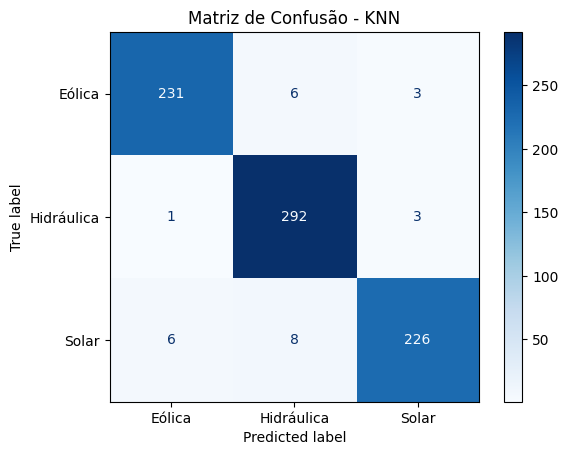


--- Regressão Logística ---
Accuracy:  0.8247
Precision: 0.8282 (Média: Macro)
Recall:    0.8214 (Média: Macro)
F1 Score:  0.8197 (Média: Macro)


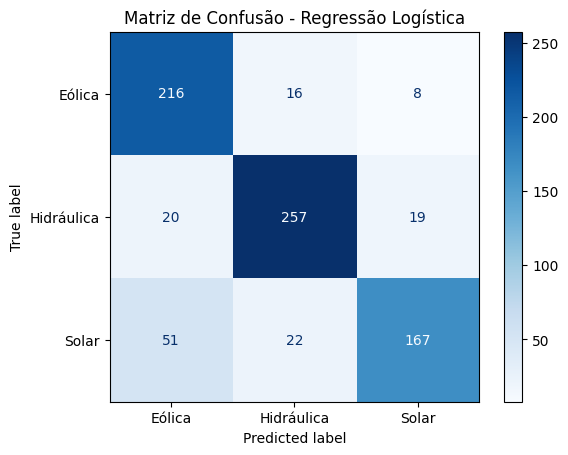


--- Random Forest ---
Accuracy:  0.9755
Precision: 0.9769 (Média: Macro)
Recall:    0.9741 (Média: Macro)
F1 Score:  0.9753 (Média: Macro)


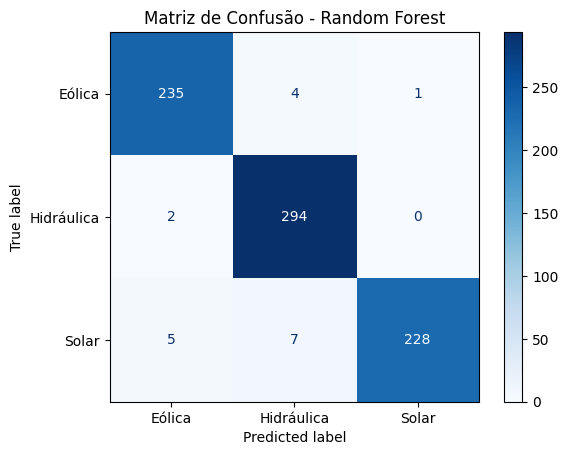

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

modelos = {
    'KNN': knn,
    'Regressão Logística': log_reg,
    'Random Forest': rf
}

for nome, modelo in modelos.items():

    y_pred = modelo.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\n--- {nome} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (Média: Macro)")
    print(f"Recall:    {rec:.4f} (Média: Macro)")
    print(f"F1 Score:  {f1:.4f} (Média: Macro)")

    cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.show()

Escolha do Modelo:
Para esta tarefa de classificação, eu escolheria o modelo Random Forest. Comparando os três algoritmos, o Random Forest apresentou o melhor desempenho global, alcançando uma Accuracy de 0.9755 e um F1-Score (Macro) de 0.9753. O modelo KNN também obteve resultados excelentes (F1-Score Macro de 0.9648), mas o Random Forest demonstrou uma ligeira superioridade na separação das classes. A Regressão Logística teve o pior desempenho (F1-Score Macro de 0.8197), o que indica que a relação entre as variáveis de entrada (potência e localização) e a fonte de energia não é puramente linear.   

Classes Mais Confundidas:
Ao analisar as matrizes de confusão, nota-se que o maior volume de erros ocorre ao tentar prever a classe Solar.

No modelo de Regressão Logística, a classe Solar é frequentemente classificada de forma incorreta como Eólica (51 vezes) e como Hidráulica (22 vezes).   

Mesmo no modelo escolhido (Random Forest), os poucos erros que ocorrem estão principalmente relacionados com a classe Solar, sendo classificada erroneamente como Eólica (5 vezes) ou Hidráulica (7 vezes).   

O modelo KNN também apresenta a mesma tendência, confundindo a energia Solar com Eólica (6 vezes) e Hidráulica (8 vezes).   

Limitações dos Dados para Aplicações Reais:
Embora o modelo Random Forest tenha atingido uma precisão superior a 97% nestes dados de teste, numa aplicação real, utilizar apenas a potência (potencia_kw) e a localização (latitude e longitude) pode não ser suficiente para garantir fiabilidade absoluta. O facto de a energia Solar ser a mais confundida ilustra bem este problema: diferentes tipos de infraestruturas podem partilhar a mesma localização geográfica. Por exemplo, uma fazenda solar e um parque eólico podem ser construídos em terrenos vizinhos (tendo coordenadas quase idênticas) e possuir potências instaladas semelhantes.

Sem variáveis adicionais — como o perfil de geração ao longo do dia, dados meteorológicos da região (incidência solar vs. regime de ventos), ou características físicas da instalação — o modelo fica dependente de correlações espaciais que podem não se verificar em novas instalações.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [11]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [12]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [13]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [14]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB
None

Valores ausentes por coluna:
 data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


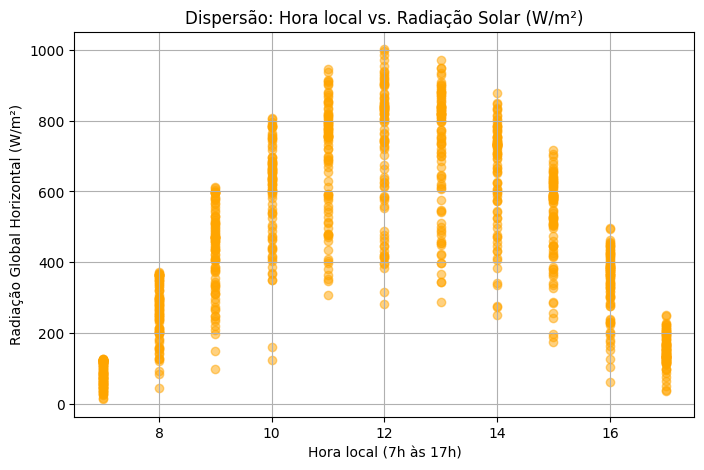

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dados_reg = pd.read_csv("meteo_regressao_orange.csv")

print("Informações do Dataset:")
print(dados_reg.info())
print("\nValores ausentes por coluna:\n", dados_reg.isna().sum())

plt.figure(figsize=(8, 5))
plt.scatter(dados_reg['hora'], dados_reg['radiacao_w_m2'], alpha=0.5, c='orange')
plt.title('Dispersão: Hora local vs. Radiação Solar (W/m²)')
plt.xlabel('Hora local (7h às 17h)')
plt.ylabel('Radiação Global Horizontal (W/m²)')
plt.grid(True)
plt.show()

X = dados_reg[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y = dados_reg['radiacao_w_m2']

temperatura_c: Temperatura do ar a 2 metros de altura, em °C.

umidade_pct: Humidade relativa do ar, em %.

nuvens_pct: Cobertura total de nuvens, em %.

vento_kmh: Velocidade do vento a 10 metros de altura, em km/h.

hora: Hora local extraída da data (apenas entre 7h e 17h).
   
radiacao_w_m2: Radiação solar global horizontal média, em W/m² (variável alvo numérico).   

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

In [17]:
lin_reg = LinearRegression()
tree_reg = DecisionTreeRegressor(random_state=42)
rf_reg = RandomForestRegressor(random_state=42)

lin_reg.fit(X_train_scaled, y_train)
tree_reg.fit(X_train_scaled, y_train)
rf_reg.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

Regressão Linear (Linear Regression): Justifica-se como um modelo base (baseline). Avalia o quão bem a radiação pode ser prevista assumindo uma relação puramente linear com variáveis como nebulosidade e hora.

Árvore de Decisão (Decision Tree Regressor): Justifica-se pela capacidade de capturar não-linearidades evidentes (a radiação sobe até ao meio-dia e desce depois, formando uma curva que um modelo linear puro tem dificuldade em ajustar).

Random Forest Regressor: Justifica-se por ser um modelo ensemble poderoso que reduz o risco de sobreajuste (overfitting) da Árvore de Decisão isolada, lidando bem com interações complexas entre cobertura de nuvens, temperatura e hora do dia.

--- Resultados da Regressão ---

Regressão Linear:
MAE: 145.20 W/m²
MSE: 30034.20 (W/m²)²
R²:  0.3598

Árvore de Decisão:
MAE: 87.63 W/m²
MSE: 15146.98 (W/m²)²
R²:  0.6772

Random Forest:
MAE: 66.71 W/m²
MSE: 7278.12 (W/m²)²
R²:  0.8449


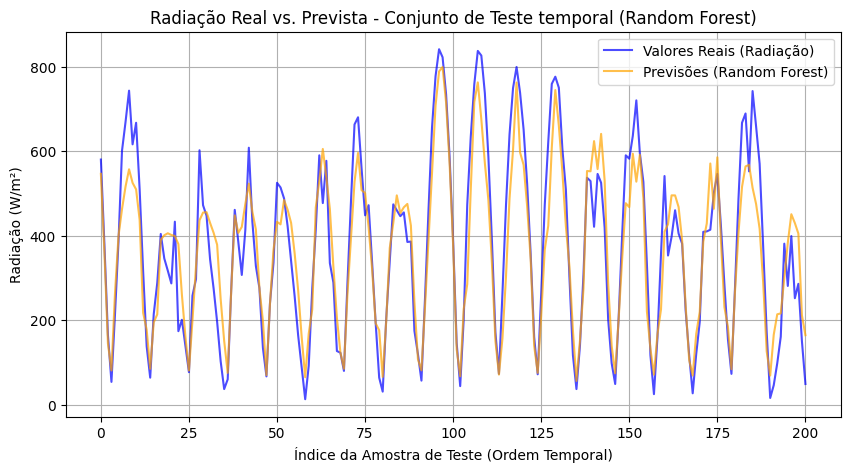

In [18]:
modelos_reg = {
    'Regressão Linear': lin_reg,
    'Árvore de Decisão': tree_reg,
    'Random Forest': rf_reg
}

melhor_modelo = None
melhores_previsoes = None
maior_r2 = -float('inf')

print("--- Resultados da Regressão ---")
for nome, modelo in modelos_reg.items():
    y_pred = modelo.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{nome}:")
    print(f"MAE: {mae:.2f} W/m²")
    print(f"MSE: {mse:.2f} (W/m²)²")
    print(f"R²:  {r2:.4f}")

    if r2 > maior_r2:
        maior_r2 = r2
        melhores_previsoes = y_pred
        melhor_modelo = nome

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Valores Reais (Radiação)', color='blue', alpha=0.7)
plt.plot(melhores_previsoes, label=f'Previsões ({melhor_modelo})', color='orange', alpha=0.7)
plt.title(f'Radiação Real vs. Prevista - Conjunto de Teste temporal ({melhor_modelo})')
plt.xlabel('Índice da Amostra de Teste (Ordem Temporal)')
plt.ylabel('Radiação (W/m²)')
plt.legend()
plt.grid(True)
plt.show()

1. Comparação e Interpretação dos Erros:
Analisando as métricas, o modelo Random Forest obteve, de forma destacada, o melhor desempenho.   

Apresentou o menor Erro Absoluto Médio (MAE de 66.71 W/m²), o que significa que as suas previsões falham, em média, por apenas ~66.7 W/m² em relação à radiação real.   

Apresentou o menor Erro Quadrático Médio (MSE de 7278.12), demonstrando que comete muito menos erros extremos (grandes desvios) do que os outros algoritmos.   

O seu R² de 0.8449 indica que o modelo consegue explicar aproximadamente 84,5% de toda a variância da radiação solar usando as cinco variáveis de entrada.   

Em contrapartida, a Regressão Linear teve um desempenho muito fraco (R² de apenas 0.3598 e um erro médio enorme de 145.20 W/m²). Isto ocorre porque a radiação solar ao longo do dia não segue um padrão linear, mas sim uma curva (sobe de manhã, atinge o pico ao meio-dia e desce à tarde), algo que um modelo linear puro é incapaz de mapear corretamente. A Árvore de Decisão conseguiu capturar parte dessa não-linearidade (R² de 0.6772), mas o Random Forest foi muito superior ao reduzir a variação (overfitting) da árvore individual.   

2. O Peso da Variável "Hora":
Como se pode observar no gráfico de linha gerado pelo Random Forest, existe um forte padrão cíclico com picos e vales muito acentuados e regulares. A variável hora tem um peso determinante na previsão, pois é ela que dita o ciclo diurno do sol (o ângulo de incidência dos raios solares). A hora estabelece, na prática, qual é o limite máximo teórico de radiação que pode existir naquele momento. As outras variáveis meteorológicas (como a nebulosidade e a humidade) atuam apenas como fatores de atenuação, reduzindo essa radiação máxima possível caso o céu esteja encoberto.   

3. Radiação Estimada vs. Energia Produzida:
A estimativa gerada por este modelo devolve a Radiação Solar Global Horizontal em W/m² (a potência bruta do sol que atinge o solo). No entanto, este valor não prevê automaticamente a energia elétrica final produzida por um sistema fotovoltaico (medida em kWh). Para calcular a energia efetivamente gerada, a radiação meteorológica teria de passar por diversas perdas e transformações físicas que o nosso modelo desconhece. Fatores cruciais como a área total dos painéis, a eficiência de conversão da tecnologia (geralmente entre 15% e 22%), o ângulo de inclinação e orientação (azimute) dos módulos, a sujidade acumulada e as perdas de potência por aquecimento das células (a alta temperatura reduz a eficiência) são indispensáveis para converter o recurso solar (W/m²) na eletricidade final que entra na rede.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)